In [ ]:
import os
import shutil
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import tensorflow as tf
print(tf.__version__)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from google.colab import drive

2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_dir_drive = "/content/drive/MyDrive/TFM/New Plant Diseases Dataset(Augmented)/train"
val_dir_drive = "/content/drive/MyDrive/TFM/New Plant Diseases Dataset(Augmented)/valid"

local_dataset_path = "/content/dataset"
local_train_dir = os.path.join(local_dataset_path, "train")
local_val_dir = os.path.join(local_dataset_path, "valid")

def copy_entire_folder(src, dst):
    if os.path.exists(dst):
        print(f"Eliminando carpeta existente: {dst}")
        shutil.rmtree(dst)
    print(f"Copiando desde {src} a {dst}")
    shutil.copytree(src, dst)
    print("Copia completa.")

copy_entire_folder(train_dir_drive, local_train_dir)
copy_entire_folder(val_dir_drive, local_val_dir)

Copiando desde /content/drive/MyDrive/TFM/New Plant Diseases Dataset(Augmented)/train a /content/dataset/train
Copia completa.
Copiando desde /content/drive/MyDrive/TFM/New Plant Diseases Dataset(Augmented)/valid a /content/dataset/valid
Copia completa.


In [ ]:
img_size = 128
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    local_train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    local_val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

class_indices_path = "/content/drive/MyDrive/TFM/class_indices.json"
with open(class_indices_path, "w") as f:
    json.dump(train_gen.class_indices, f)
print("Class indices guardats.")

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Class indices guardats.


In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
best_model_path = "/content/drive/MyDrive/TFM/millor_model_total.keras"
early_stopping = EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)
checkpoint = ModelCheckpoint(best_model_path, monitor='val_accuracy', save_best_only=True, verbose=1)

total_epochs = 40
block_size = 5

all_loss, all_val_loss = [], []
all_accuracy, all_val_accuracy = [], []

for start_epoch in range(0, total_epochs, block_size):
    end_epoch = start_epoch + block_size
    print(f"\nEntrenant de l'època {start_epoch + 1} a {end_epoch}")

    history = model.fit(
        train_gen,
        epochs=end_epoch,
        initial_epoch=start_epoch,
        validation_data=val_gen,
        callbacks=[early_stopping, checkpoint]
    )
    all_loss.extend(history.history['loss'])
    all_val_loss.extend(history.history['val_loss'])
    all_accuracy.extend(history.history['accuracy'])
    all_val_accuracy.extend(history.history['val_accuracy'])

    print(f" Bloc {start_epoch + 1}-{end_epoch} completat.")

    if early_stopping.stopped_epoch > 0:
        print(" Early stopping activat.")
        break


Entrenant de l'època 1 a 5
Epoch 1/5
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7315 - loss: 0.9396
Epoch 1: val_accuracy improved from None to 0.91430, saving model to /content/drive/MyDrive/TFM/millor_model_total.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 132s 56ms/step - accuracy: 0.8243 - loss: 0.5759 - val_accuracy: 0.9143 - val_loss: 0.2622
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8961 - loss: 0.3132
Epoch 2: val_accuracy improved from 0.91430 to 0.93165, saving model to /content/drive/MyDrive/TFM/millor_model_total.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 111s 50ms/step - accuracy: 0.8971 - loss: 0.3105 - val_accuracy: 0.9317 - val_loss: 0.2008
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9120 - loss: 0.2601
Epoch 3: val_accuracy improved from 0.93165 to 0.93973, saving model to /content/drive/MyDrive/TFM/millor_model_total.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 142s 50ms/step - accuracy: 0.9133 - loss: 0.2582 - val_accuracy:

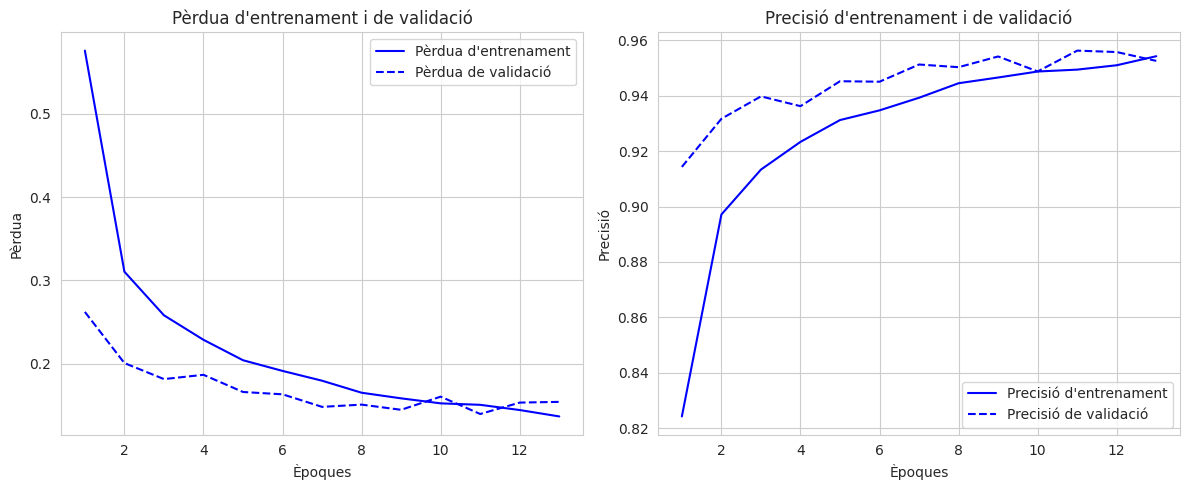

In [ ]:
epochs = range(1, len(all_loss) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, all_loss, 'b', label='Pèrdua d\'entrenament')
plt.plot(epochs, all_val_loss, 'b--', label='Pèrdua de validació')
plt.title('Pèrdua d\'entrenament i de validació')
plt.xlabel('Èpoques')
plt.ylabel('Pèrdua')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, all_accuracy, 'b', label='Precisió d\'entrenament')
plt.plot(epochs, all_val_accuracy, 'b--', label='Precisió de validació')
plt.title('Precisió d\'entrenament i de validació')
plt.xlabel('Èpoques')
plt.ylabel('Precisió')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFM/entrenament.jpg', dpi=300, bbox_inches='tight')

plt.show()

#Proves del model

In [1]:
from google.colab import drive
drive.mount('/content/drive')
from tensorflow.keras.models import load_model

MODEL_PATH = "/content/drive/MyDrive/TFM/millor_model_total.keras"

model = load_model(MODEL_PATH)
model.summary()

Mounted at /content/drive


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,271,092 (12.48 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 675,406 (2.58 MB)

In [ ]:
import os
import shutil
def copy_entire_folder(src, dst):
    if os.path.exists(dst):
        print(f"Eliminando carpeta existente: {dst}")
        shutil.rmtree(dst)
    print(f"Copiando desde {src} a {dst}")
    shutil.copytree(src, dst)
    print("Copia completa.")

test_dir_drive = "/content/drive/MyDrive/TFM/test"
local_dataset_path = "/content/dataset"
local_test_dir = os.path.join(local_dataset_path, "test")
copy_entire_folder(test_dir_drive, local_test_dir)

Copiando desde /content/drive/MyDrive/TFM/test a /content/dataset/test
Copia completa.


In [ ]:
with open(class_indices_path, "r") as f:
    class_indices = json.load(f)
class_labels = {v: k for k, v in class_indices.items()}

import re
from difflib import SequenceMatcher

def normalize_label(label):
    label = label.lower()
    label = label.replace('_', '')
    label = label.replace(' ', '')
    label = re.sub(r'[^a-z]', '', label)
    return label

def get_true_label_from_filename(filename):
    name = filename.rsplit('.', 1)[0]
    name = re.sub(r'\d+', '', name)  
    return name

def best_match_label(true_label_raw, class_labels_list):
    true_norm = normalize_label(true_label_raw)
    best_label = None
    best_ratio = 0
    for label in class_labels_list:
        label_norm = normalize_label(label)
        ratio = SequenceMatcher(None, true_norm, label_norm).ratio()
        if ratio > best_ratio:
            best_ratio = ratio
            best_label = label
    return best_label

correct = 0
total = len(test_images)

for img_name in test_images:
    img_path = os.path.join(local_test_dir, img_name)
    img_pre = preprocess_image(img_path)  # tu función para preparar la imagen
    pred = model.predict(img_pre)
    pred_class = np.argmax(pred, axis=1)[0]
    pred_label = class_labels[pred_class]

    true_label_raw = get_true_label_from_filename(img_name)
    true_label = best_match_label(true_label_raw, class_labels.values())

    print(f"Imatge: {img_name} - Real: {true_label} - Predicció: {pred_label}")

    if normalize_label(true_label) == normalize_label(pred_label):
        correct += 1

accuracy = correct / total
print(f"\nPrecissió a test: {accuracy * 100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Imatge: AppleScab3.JPG - Real: Apple___Apple_scab - Predicció: Apple___Apple_scab
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
Imatge: PotatoEarlyBlight3.JPG - Real: Potato___Early_blight - Predicció: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
Imatge: AppleScab2.JPG - Real: Apple___Apple_scab - Predicció: Apple___Apple_scab
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
Imatge: PotatoHealthy1.JPG - Real: Potato___healthy - Predicció: Potato___healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
Imatge: TomatoEarlyBlight6.JPG - Real: Tomato___Early_blight - Predicció: Tomato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
Imatge: AppleCedarRust2.JPG - Real: Apple___Cedar_apple_rust - Predicció: Apple___Cedar_apple_rust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
Imatge: TomatoYellowCurlVirus1.JPG - Real: Tomato___Tomato_Yellow_Leaf_Curl_Virus - Predicció: Tomato___Tomato_Yellow_Leaf_Curl_Virus
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
Imatge: TomatoYell

Com es veu la precissió al test es lleugerament inferior a la de validació pero igualment alta confirmant la validesa del model